# Advanced Machine Learning (CS60073)
## **Assignment 1:** Probabilistic Bayesian Modeling and Probabilistic Supervised Learning (Total Marks: 80)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)


## Part A: Bayesian Parameter Estimation (40 Marks)

### A1. Multivariate Gaussian with Normal-Inverse-Wishart Prior (10 Marks)

a) Generate 250 samples from a 2-D Gaussian distribution with     
$$
\mu =
\begin{bmatrix}
3\\
1
\end{bmatrix},
\qquad
\Sigma =
\begin{bmatrix}
2.5 & 0.8\\
0.8 & 1.2
\end{bmatrix}
$$

b) Use a Normal-Inverse-Wishart prior to estimate the posterior distribution.

c) Draw posterior covariance ellipses for multiple posterior samples.

d) Discuss how uncertainty decreases as the number of observations increases.


In [2]:
# generate 250 2-D Gaussian samples
mu_true = np.array([3, 1])
sigma_true = np.array([[2.5, 0.8], [0.8, 1.2]])
n = 250
samples = np.random.multivariate_normal(mean=mu_true, cov=sigma_true, size=n)

print("MULTIVARIATE 2-D GAUSSIAN SAMPLES")
print("Shape of samples:", samples.shape)
print("Sample mean:\n", np.mean(samples, axis=0))
print("Sample covariance:\n", np.cov(samples, rowvar=False))

MULTIVARIATE 2-D GAUSSIAN SAMPLES
Shape of samples: (250, 2)
Sample mean:
 [2.99171025 1.00715987]
Sample covariance:
 [[2.49277009 0.80538843]
 [0.80538843 1.14041099]]


In [3]:
# initialize Normal Inverse-Wishart prior parameters
d = samples.shape[1]    
mu_0 = np.zeros(d)        
kappa_0 = 1.0
nu_0 = d + 1
Lambda_0 = np.eye(d)    # a 2-D array with ones on the diagonal and zeros elsewhere

print("\nPrior parameters:")
print("mu_0 =", mu_0)
print("kappa_0 =", kappa_0)
print("nu_0 =", nu_0)
print("Lambda_0 =\n", Lambda_0)

# compute sufficient statistics
x_bar = np.mean(samples, axis=0)                # sample mean
S = (samples - x_bar).T @ (samples - x_bar)     # scatter matrix

# estimate posterior parameters
kappa_n = kappa_0 + n
nu_n = nu_0 + n
mu_n = (kappa_0 * mu_0 + n * x_bar) / kappa_n
Lambda_n = (Lambda_0 + S + (kappa_0 * n / kappa_n) * np.outer(x_bar - mu_0, x_bar - mu_0))
posterior_covariance_mean = (Lambda_n / (nu_n - d - 1))

print("\nPosterior parameters:")
print("mu_n =", mu_n)
print("kappa_n =", kappa_n)
print("nu_n =", nu_n)
print("Lambda_n =\n", Lambda_n)
print("Expected posterior covariance:\n", posterior_covariance_mean)


Prior parameters:
mu_0 = [0. 0.]
kappa_0 = 1.0
nu_0 = 3
Lambda_0 =
 [[1. 0.]
 [0. 1.]]

Posterior parameters:
mu_n = [2.97979109 1.00314728]
kappa_n = 251.0
nu_n = 253
Lambda_n =
 [[630.61442517 203.54284392]
 [203.54284392 285.97266604]]
Expected posterior covariance:
 [[2.5224577  0.81417138]
 [0.81417138 1.14389066]]


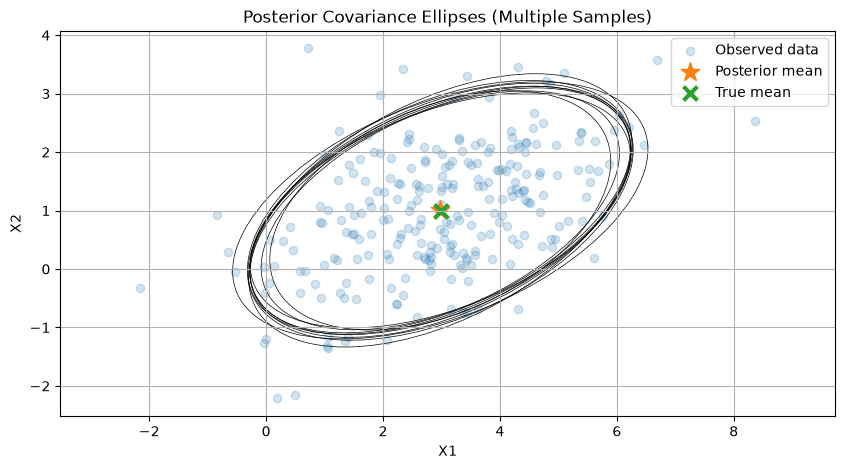

In [4]:
from scipy.stats import invwishart
from matplotlib.patches import Ellipse

# generate multiple posterior samples
n_posterior_samples = 10
posterior_covariances = []

for i in range(n_posterior_samples):
    sigma_sample = invwishart.rvs(df=nu_n, scale=Lambda_n)
    posterior_covariances.append(sigma_sample)

def draw_covariance_ellipse(mean, covariance, ax, n_std=2):
    """
    Draw an n_std covariance ellipse.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)  # eigenvalue decomposition
    order = eigenvalues.argsort()[::-1]                     # sort eigenvalues in descending order
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]    
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))  # angle of the largest eigenvector

    # ellipse dimensions
    width = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, linewidth=0.5)
    ax.add_patch(ellipse)

# plot posterior covariance ellipses
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.2, label="Observed data")

# draw ellipse for each posterior covariance sample
for i, sigma_sample in enumerate(posterior_covariances):
    draw_covariance_ellipse(mu_n, sigma_sample, ax, n_std=2)

ax.scatter(mu_n[0], mu_n[1], marker="*", s=200, label="Posterior mean")                 # posterior mean
ax.scatter(mu_true[0], mu_true[1], marker="x", s=100, linewidths=3, label="True mean")  # true mean

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Posterior Covariance Ellipses (Multiple Samples)")
ax.legend()
ax.axis("equal")
ax.grid(True)
plt.show()

**Uncertainty vs Number of Observations**

As the ***number of observations (n) increases, the posterior uncertainty decreases*** because more data provide more information about the unknown parameters.
- `kappa_n = kappa_0 + n` increases, ***reducing uncertainty in the posterior mean***.
- `nu_n = nu_0 + n` increases, making the ***posterior covariance more concentrated***.
- With fewer observations, posterior covariance ellipses vary more widely.
- With more observations, the ellipses become smaller and more similar.
- For `n=250`, the estimated mean and covariance are already close to the true values.
$$
n \uparrow \;\Rightarrow\; \text{posterior uncertainty} \downarrow
$$

### A2. Bernoulli Distribution with Beta Prior (10 Marks)

a) Generate 120 Bernoulli observations with success probability p = 0.72.

b) Use two Beta priors:
Beta(1, 1), Beta(8, 3).

c) Compute the posterior distribution for each prior.

d) Compare the MLE, MAP, and posterior mean estimates.

e) Plot the prior, likelihood, and posterior distributions.

In [9]:
# generate 120 Bernoulli observations
p_true = 0.72
n = 120
observations = np.random.binomial(n=1, p=p_true, size=n)
successes = np.sum(observations)
failures = n - successes

print(f"BERNOULLI({p_true}) OBSERVATIONS")
print("Number of observations:", n)
print("Number of successes:", successes)
print("Number of failures:", failures)
print("Observed success probability:", successes / n)

BERNOULLI(0.72) OBSERVATIONS
Number of observations: 120
Number of successes: 89
Number of failures: 31
Observed success probability: 0.7416666666666667


In [20]:
# initialize params for two prior (Beta distributions)
alpha_1, beta_1 = 1, 1
alpha_2, beta_2 = 8, 3

print("Beta Prior parameters")
print(f'alpha_1 = {alpha_1}, beta_1 = {beta_1}')
print(f'alpha_2 = {alpha_2}, beta_2 = {beta_2}')

Beta Prior parameters
alpha_1 = 1, beta_1 = 1
alpha_2 = 8, beta_2 = 3


In [13]:
# compute posterior parameters for Beta(1, 1)
alpha_n_1 = alpha_1 + successes
beta_n_1 = beta_1 + failures

print("\nPosterior for Beta(1, 1):")
print("alpha_n_1 =", alpha_n_1)
print("beta_n_1 =", beta_n_1)

# compute posterior parameters for Beta(8, 3)
alpha_n_2 = alpha_2 + successes
beta_n_2 = beta_2 + failures

print("\nPosterior for Beta(8, 3):")
print("alpha_n_2 =", alpha_n_2)
print("beta_n_2 =", beta_n_2)


Posterior for Beta(1, 1):
alpha_n_1 = 90
beta_n_1 = 32

Posterior for Beta(8, 3):
alpha_n_2 = 97
beta_n_2 = 34


In [14]:
# compute MLE
mle = successes / n
print("MLE =", mle)

# compute MAP and posterior mean for Beta(1, 1)
map_1 = (successes + alpha_1 - 1) / (n + alpha_1 + beta_1 - 2)
posterior_mean_1 = alpha_n_1 / (alpha_n_1 + beta_n_1)

print("\nEstimates for Beta(1, 1):")
print("MAP =", map_1)
print("Posterior mean =", posterior_mean_1)

# compute MAP and posterior mean for Beta(8, 3)
map_2 = (successes + alpha_2 - 1) / (n + alpha_2 + beta_2 - 2)
posterior_mean_2 = alpha_n_2 / (alpha_n_2 + beta_n_2)

print("\nEstimates for Beta(8, 3):")
print("MAP =", map_2)
print("Posterior mean =", posterior_mean_2)

MLE = 0.7416666666666667

Estimates for Beta(1, 1):
MAP = 0.7416666666666667
Posterior mean = 0.7377049180327869

Estimates for Beta(8, 3):
MAP = 0.7441860465116279
Posterior mean = 0.7404580152671756


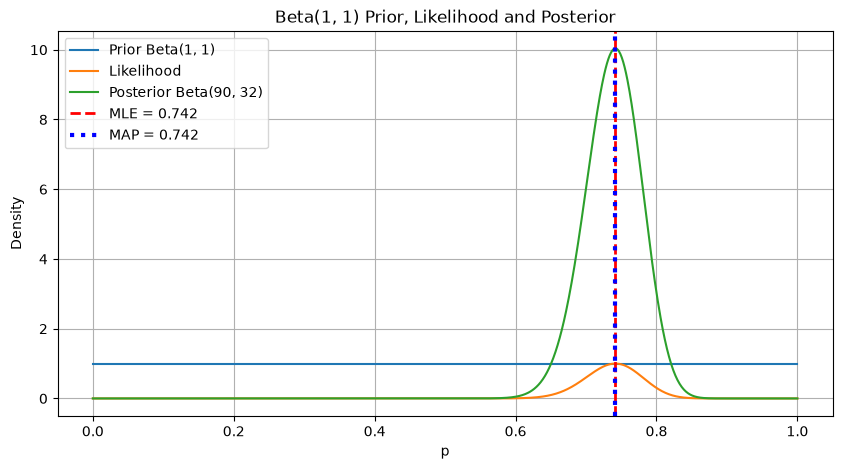

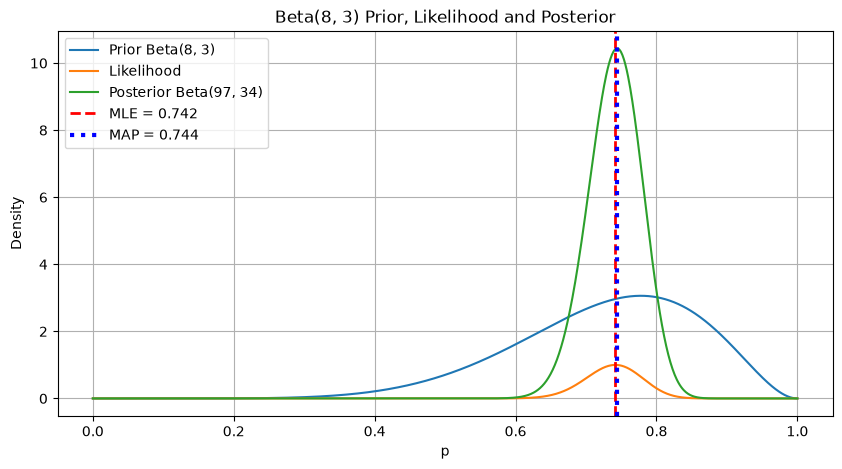

In [15]:
from scipy.stats import binom, beta

# create probability values for plotting
p_values = np.linspace(0, 1, 1000)

# compute prior, likelihood and posterior for Beta(1, 1)
prior_1 = beta.pdf(p_values, alpha_1, beta_1)
likelihood = binom.pmf(successes, n, p_values)
likelihood = likelihood / np.max(likelihood)   # normalize for comparison
posterior_1 = beta.pdf(p_values, alpha_n_1, beta_n_1)

# compute prior and posterior for Beta(8, 3)
prior_2 = beta.pdf(p_values, alpha_2, beta_2)
posterior_2 = beta.pdf(p_values, alpha_n_2, beta_n_2)

# plot Beta(1, 1) prior, likelihood and posterior
plt.figure(figsize=(10, 5))
plt.plot(p_values, prior_1, label="Prior Beta(1, 1)")
plt.plot(p_values, likelihood, label="Likelihood")
plt.plot(p_values, posterior_1, label=f"Posterior Beta({alpha_n_1}, {beta_n_1})")
plt.axvline(mle, color="red", linestyle="--", linewidth=2, label=f"MLE = {mle:.3f}")
plt.axvline(map_1, color="blue", linestyle=":", linewidth=3, label=f"MAP = {map_1:.3f}")
plt.xlabel("p")
plt.ylabel("Density")
plt.title("Beta(1, 1) Prior, Likelihood and Posterior")
plt.legend()
plt.grid(True)
plt.show()

# plot Beta(8, 3) prior, likelihood and posterior
plt.figure(figsize=(10, 5))
plt.plot(p_values, prior_2, label="Prior Beta(8, 3)")
plt.plot(p_values, likelihood, label="Likelihood")
plt.plot(p_values, posterior_2, label=f"Posterior Beta({alpha_n_2}, {beta_n_2})")
plt.axvline(mle, color="red", linestyle="--", linewidth=2, label=f"MLE = {mle:.3f}")
plt.axvline(map_2, color="blue", linestyle=":", linewidth=3, label=f"MAP = {map_2:.3f}")
plt.xlabel("p")
plt.ylabel("Density")
plt.title("Beta(8, 3) Prior, Likelihood and Posterior")
plt.legend()
plt.grid(True)
plt.show()

**Plot Observations**
- Both posteriors are ***concentrated near the observed success probability***.
- `Beta(1, 1)` is mainly ***data-driven***, while `Beta(8, 3)` shows ***slight prior influence***.
- MLE and MAP are ***very close*** due to the large sample size.

### A3. Univariate Gaussian Bayesian Estimation (10 Marks)
Generate 150 samples from
$$
\mathcal{N}(4, 1.8)
$$
Perform Bayesian inference for:

a) Known variance, unknown mean using a Gaussian prior.

b) Unknown mean and variance using a Normal-Inverse-Gamma prior.

c) Derive the analytical posterior.

d) Compare prior and posterior distributions graphically.


In [18]:
# generate 150 samples from N(4, 1.8)
mu_true = 4
sigma_true = 1.8
n = 150
samples = np.random.normal(loc=mu_true, scale=np.sqrt(sigma_true), size=n)

print(f"NORMAL({mu_true}, {sigma_true}) SAMPLES")
print("Shape of samples:", samples.shape)
print("Sample mean:", np.mean(samples))
print("Sample variance:", np.var(samples, ddof=1))

NORMAL(4, 1.8) SAMPLES
Shape of samples: (150,)
Sample mean: 4.0851429009005855
Sample variance: 1.8021085876786467


In [19]:
# known variance, unknown mean using Gaussian prior
mu_0 = 0
sigma_0 = 10

print("\nGaussian Prior parameters:")
print("mu_0 =", mu_0)
print("sigma_0 =", sigma_0)

# compute sufficient statistics
x_bar = np.mean(samples)

# estimate posterior parameters
sigma_n = 1 / (1 / sigma_0**2 + n / sigma_true)
mu_n = (sigma_true * mu_0 + sigma_0 * n * x_bar) / (sigma_true + n * sigma_0)

print("\nPosterior parameters (Known Variance, Unknown Mean):")
print("posterior mean =", mu_n)
print("posterior variance =", sigma_n)


Gaussian Prior parameters:
mu_0 = 0
sigma_0 = 10

Posterior parameters (Known Variance, Unknown Mean):
posterior mean = 4.080246604974616
posterior variance = 0.011998560172779267


In [21]:
# unknown mean and variance using Normal-Inverse-Gamma prior
mu_0 = 0
kappa_0 = 1
alpha_0 = 2
beta_0 = 2

print("\nNormal-Inverse-Gamma prior parameters:")
print("mu_0 =", mu_0)
print("kappa_0 =", kappa_0)
print("alpha_0 =", alpha_0)
print("beta_0 =", beta_0)

# compute sufficient statistics
x_bar = np.mean(samples)
S = np.sum((samples - x_bar)**2)

# estimate posterior parameters
kappa_n = kappa_0 + n
alpha_n = alpha_0 + n / 2
mu_n = (kappa_0 * mu_0 + n * x_bar) / kappa_n
beta_n = (beta_0 + 0.5 * S + (kappa_0 * n / (2 * kappa_n)) * (x_bar - mu_0)**2)
posterior_variance_exp = beta_n / (alpha_n - 1)

print("\nPosterior parameters (Unknown Mean & Variance)")
print("Posterior mean =", mu_n)
print("kappa_n =", kappa_n)
print("alpha_n =", alpha_n)
print("beta_n =", beta_n)
print("Posterior expected variance =", posterior_variance_exp)


Normal-Inverse-Gamma prior parameters:
mu_0 = 0
kappa_0 = 1
alpha_0 = 2
beta_0 = 2

Posterior parameters (Unknown Mean & Variance)
Posterior mean = 4.058088974404555
kappa_n = 151
alpha_n = 77.0
beta_n = 144.54602646456505
Posterior expected variance = 1.90192140084954


**Analytical Derivation of Posterior Distributions**

***Case 1: Known Variance and Unknown Mean***

Assume the observations are independently drawn from a Gaussian distribution:

$$
x_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2),
\qquad i=1,\ldots,n
$$

where the variance $\sigma^2$ is known and the mean $\mu$ is unknown.

***Step 1: Likelihood***

The likelihood of the observed data is

$$
p(\mathbf{x}\mid\mu)
=
\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[
-\frac{(x_i-\mu)^2}{2\sigma^2}
\right]
$$

Therefore,

$$
p(\mathbf{x}\mid\mu)
=
(2\pi\sigma^2)^{-n/2}
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^{n}(x_i-\mu)^2
\right]
$$

Ignoring terms that do not depend on $\mu$,

$$
p(\mathbf{x}\mid\mu)
\propto
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^{n}(x_i-\mu)^2
\right]
$$

***Step 2: Gaussian Prior***

Choose a Gaussian prior for the unknown mean:

$$
\mu \sim \mathcal{N}(\mu_0,\sigma_0^2)
$$

Therefore,

$$
p(\mu)
\propto
\exp\left[
-\frac{(\mu-\mu_0)^2}{2\sigma_0^2}
\right]
$$

***Step 3: Apply Bayes' Rule***

The posterior is

$$
p(\mu\mid\mathbf{x})
\propto
p(\mathbf{x}\mid\mu)p(\mu)
$$

Substituting the likelihood and prior:

$$
p(\mu\mid\mathbf{x})
\propto
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^{n}(x_i-\mu)^2
-\frac{(\mu-\mu_0)^2}{2\sigma_0^2}
\right]
$$

***Step 4: Expand the Squared Terms***

First,

$$
\sum_{i=1}^{n}(x_i-\mu)^2
=
\sum_{i=1}^{n}x_i^2
-2\mu\sum_{i=1}^{n}x_i
+n\mu^2
$$

Since

$$
\sum_{i=1}^{n}x_i=n\bar{x}
$$

we get

$$
\sum_{i=1}^{n}(x_i-\mu)^2
=
\sum_{i=1}^{n}x_i^2
-2n\bar{x}\mu
+n\mu^2
$$

Also,

$$
(\mu-\mu_0)^2
=
\mu^2-2\mu\mu_0+\mu_0^2
$$

Substituting and collecting the terms involving $\mu$:

$$
\boxed{
p(\mu\mid\mathbf{x})
\propto
\exp\left[
-\frac{1}{2}
\left(
\left(
\frac{n}{\sigma^2}
+
\frac{1}{\sigma_0^2}
\right)\mu^2
-
2
\left(
\frac{n\bar{x}}{\sigma^2}
+
\frac{\mu_0}{\sigma_0^2}
\right)\mu
\right)
\right]
}
$$

***Step 5: Complete the Square***

Define the posterior precision:

$$
\frac{1}{\sigma_n^2}
=
\frac{n}{\sigma^2}
+
\frac{1}{\sigma_0^2}
$$

Therefore,

$$
\boxed{
\sigma_n^2
=
\frac{1}{
\frac{1}{\sigma_0^2}
+
\frac{n}{\sigma^2}
}
}
$$

The posterior mean is

$$
\boxed{
\mu_n
=
\sigma_n^2
\left(
\frac{\mu_0}{\sigma_0^2}
+
\frac{n\bar{x}}{\sigma^2}
\right)
}
$$

Thus,

$$
\boxed{
\mu\mid\mathbf{x}
\sim
\mathcal{N}(\mu_n,\sigma_n^2)
}
$$

where

$$
\boxed{
\mu_n
=
\frac{
\frac{\mu_0}{\sigma_0^2}
+
\frac{n\bar{x}}{\sigma^2}
}{
\frac{1}{\sigma_0^2}
+
\frac{n}{\sigma^2}
}
}
$$


**Case 2: Unknown Mean and Unknown Variance**

Now assume both $\mu$ and $\sigma^2$ are unknown.

The likelihood is

$$
x_i\mid\mu,\sigma^2
\sim
\mathcal{N}(\mu,\sigma^2)
$$

We use a Normal-Inverse-Gamma prior.

***Step 1: Likelihood***

The likelihood is

$$
p(\mathbf{x}\mid\mu,\sigma^2)
=
(2\pi\sigma^2)^{-n/2}
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^{n}(x_i-\mu)^2
\right]
$$

Using the identity

$$
\sum_{i=1}^{n}(x_i-\mu)^2
=
\sum_{i=1}^{n}(x_i-\bar{x})^2
+
n(\bar{x}-\mu)^2
$$

define

$$
S=\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

Therefore,

$$
p(\mathbf{x}\mid\mu,\sigma^2)
\propto
(\sigma^2)^{-n/2}
\exp\left[
-\frac{1}{2\sigma^2}
\left(
S+n(\bar{x}-\mu)^2
\right)
\right]
$$

***Step 2: Normal-Inverse-Gamma Prior***

The prior is

$$
\mu\mid\sigma^2
\sim
\mathcal{N}
\left(
\mu_0,
\frac{\sigma^2}{\kappa_0}
\right)
$$

and

$$
\sigma^2
\sim
\operatorname{Inverse\text{-}Gamma}
(\alpha_0,\beta_0)
$$

The conditional Gaussian prior is

$$
p(\mu\mid\sigma^2)
\propto
(\sigma^2)^{-1/2}
\exp\left[
-\frac{\kappa_0(\mu-\mu_0)^2}{2\sigma^2}
\right]
$$

The Inverse-Gamma prior is

$$
p(\sigma^2)
\propto
(\sigma^2)^{-(\alpha_0+1)}
\exp\left[
-\frac{\beta_0}{\sigma^2}
\right]
$$

Therefore, the joint prior is

$$
p(\mu,\sigma^2)
\propto
(\sigma^2)^{-(\alpha_0+3/2)}
\exp\left[
-\frac{1}{\sigma^2}
\left(
\beta_0
+
\frac{\kappa_0}{2}(\mu-\mu_0)^2
\right)
\right]
$$

***Step 3: Apply Bayes' Rule***

The joint posterior is

$$
p(\mu,\sigma^2\mid\mathbf{x})
\propto
p(\mathbf{x}\mid\mu,\sigma^2)
p(\mu,\sigma^2)
$$

Substituting:

$$
\boxed{
p(\mu,\sigma^2\mid\mathbf{x})
\propto
(\sigma^2)^{-(\alpha_0+n/2+3/2)}
\times
\exp\left[
-\frac{1}{\sigma^2}
\left(
\beta_0
+
\frac{S}{2}
+
\frac{n}{2}(\bar{x}-\mu)^2
+
\frac{\kappa_0}{2}(\mu-\mu_0)^2
\right)
\right]
}
$$

***Step 4: Combine the Quadratic Terms in $\mu$***

Consider

$$
n(\bar{x}-\mu)^2
+
\kappa_0(\mu-\mu_0)^2
$$

Expanding:

$$
n(\mu-\bar{x})^2
+
\kappa_0(\mu-\mu_0)^2
$$

$$
=
(n+\kappa_0)\mu^2
-
2(n\bar{x}+\kappa_0\mu_0)\mu
+
n\bar{x}^2
+
\kappa_0\mu_0^2
$$

Define

$$
\boxed{
\kappa_n=\kappa_0+n
}
$$

and

$$
\boxed{
\mu_n=
\frac{\kappa_0\mu_0+n\bar{x}}
{\kappa_n}
}
$$

Completing the square gives

$$
n(\bar{x}-\mu)^2
+
\kappa_0(\mu-\mu_0)^2
=
\kappa_n(\mu-\mu_n)^2
+
\frac{\kappa_0n}{\kappa_n}
(\bar{x}-\mu_0)^2
$$

Therefore,

$$
\boxed{
\beta_n
=
\beta_0
+
\frac{S}{2}
+
\frac{\kappa_0n}{2\kappa_n}
(\bar{x}-\mu_0)^2
}
$$

***Step 5: Update $\alpha$***

From the power of $\sigma^2$:

$$
\alpha_n
=
\alpha_0+\frac{n}{2}
$$

Therefore,

$$
\boxed{
\alpha_n=\alpha_0+\frac{n}{2}
}
$$

***Step 6: Posterior Distribution***

The posterior remains Normal-Inverse-Gamma:

$$
\boxed{
(\mu,\sigma^2)\mid\mathbf{x}
\sim
NIG(\mu_n,\kappa_n,\alpha_n,\beta_n)
}
$$

with

$$
\boxed{
\kappa_n=\kappa_0+n
}
$$

$$
\boxed{
\mu_n=
\frac{\kappa_0\mu_0+n\bar{x}}
{\kappa_0+n}
}
$$

$$
\boxed{
\alpha_n=\alpha_0+\frac{n}{2}
}
$$

$$
\boxed{
\beta_n=
\beta_0+
\frac{S}{2}
+
\frac{\kappa_0n}{2(\kappa_0+n)}
(\bar{x}-\mu_0)^2
}
$$

The conditional posterior of the mean is

$$
\boxed{
\mu\mid\sigma^2,\mathbf{x}
\sim
\mathcal{N}
\left(
\mu_n,
\frac{\sigma^2}{\kappa_n}
\right)
}
$$

The posterior of the variance is

$$
\boxed{
\sigma^2\mid\mathbf{x}
\sim
\operatorname{Inverse\text{-}Gamma}
(\alpha_n,\beta_n)
}
$$

Therefore, the posterior expected variance is

$$
\boxed{
E[\sigma^2\mid\mathbf{x}]
=
\frac{\beta_n}{\alpha_n-1}
}
$$

Finally, integrating out $\sigma^2$ gives the marginal posterior of $\mu$:

$$
\boxed{
\mu\mid\mathbf{x}
\sim
t_{2\alpha_n}
\left(
\mu_n,
\sqrt{
\frac{\beta_n}{\alpha_n\kappa_n}
}
\right)
}
$$


**Summary of Posterior Parameters**

| Case | Posterior Distribution | Parameters |
|---|---|---|
| Known $\sigma^2$, unknown $\mu$ | $\mathcal{N}(\mu_n,\sigma_n^2)$ | $\mu_n,\sigma_n^2$ |
| Unknown $\mu,\sigma^2$ | $NIG(\mu_n,\kappa_n,\alpha_n,\beta_n)$ | $\mu_n,\kappa_n,\alpha_n,\beta_n$ |

For the first case:

$$
\sigma_n^2=
\frac{1}{
\frac{1}{\sigma_0^2}+\frac{n}{\sigma^2}
}
$$

For the second case:

$$
\kappa_n=\kappa_0+n
$$

$$
\mu_n=
\frac{\kappa_0\mu_0+n\bar{x}}
{\kappa_n}
$$

$$
\alpha_n=\alpha_0+\frac{n}{2}
$$

$$
\beta_n=
\beta_0+
\frac{S}{2}
+
\frac{\kappa_0n}{2\kappa_n}
(\bar{x}-\mu_0)^2
$$

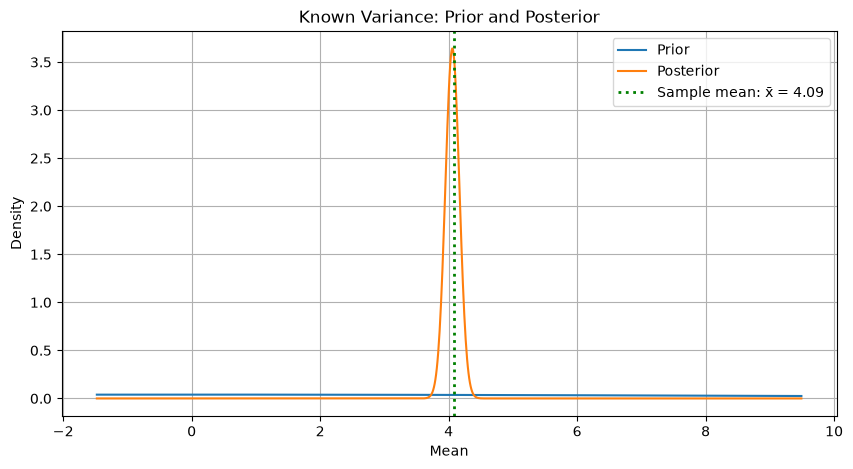

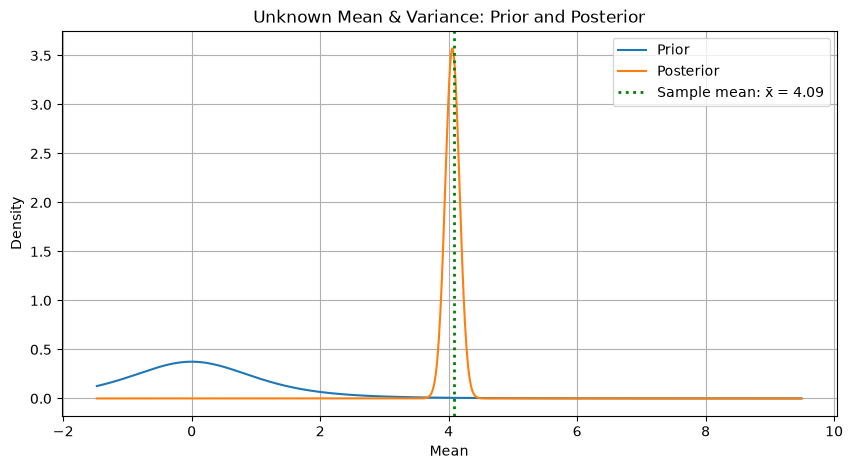

In [22]:
from scipy.stats import norm, t

# create values for plotting
x_values = np.linspace(min(samples) - 2, max(samples) + 2, 1000)

# Case-1: known variance & unknown mean
prior_pdf = norm.pdf(x_values, mu_0, sigma_0)
posterior_pdf = norm.pdf(x_values, mu_n, np.sqrt(sigma_n))

# plot the distributions
plt.figure(figsize=(10, 5))
plt.plot(x_values, prior_pdf, label=f"Prior")
plt.plot(x_values, posterior_pdf, label=f"Posterior")
plt.axvline(x_bar, color="green", linestyle=":", linewidth=2, label=f"Sample mean: x̄ = {x_bar:.2f}")
plt.xlabel("Mean")
plt.ylabel("Density")
plt.title("Known Variance: Prior and Posterior")
plt.legend()
plt.grid(True)
plt.show()

# Case-2: unknown mean & variance
# Marginal posterior distribution of mean
posterior_mean_df = 2 * alpha_n
posterior_mean_scale = np.sqrt(beta_n / (alpha_n * kappa_n))

posterior_mean_pdf = t.pdf(x_values, df=posterior_mean_df, loc=mu_n, scale=posterior_mean_scale)

# Prior distribution of mean
prior_mean_pdf = t.pdf(x_values, df=2 * alpha_0, loc=mu_0, scale=np.sqrt(beta_0 / (alpha_0 * kappa_0)))

# plot the distributions
plt.figure(figsize=(10, 5))
plt.plot(x_values, prior_mean_pdf, label=f"Prior")
plt.plot(x_values, posterior_mean_pdf, label=f"Posterior")
plt.axvline(x_bar, color="green", linestyle=":", linewidth=2, label=f"Sample mean: x̄ = {x_bar:.2f}")
plt.xlabel("Mean")
plt.ylabel("Density")
plt.title("Unknown Mean & Variance: Prior and Posterior")
plt.legend()
plt.grid(True)
plt.show()

**Plot Observations**
- For both cases, the ***posterior distribution is more concentrated around the sample mean*** than the prior.
- The posterior distributions are centered close to the ***sample mean $\bar{x}$***, indicating that the observed data strongly influences the estimate of the unknown mean.

### A4. Categorical Distribution with Dirichlet Prior (10 Marks)
a) Simulate 350 observations from a 4-class categorical distribution
$$
[0.15, 0.35, 0.30, 0.20].
$$

b) Assume a Dirichlet prior
$$
(3, 2, 3, 2).
$$

c) Compute the posterior distribution.

d) Compute posterior predictive probabilities.

e) Visualize the prior and posterior (simplex or equivalent visualization).

In [27]:
# generate class counts from a categorical distribution
probabilities = [0.15, 0.35, 0.30, 0.20]
n = 350
class_counts = np.random.multinomial(n, probabilities)

print("MULTINOULLI OBSERVATIONS:")
print("True probabilities =", probabilities)
print("Number of observations =", n)
print("Class\t\tCount\t\tEmpirical probability")
for i, count in enumerate(class_counts):
    print(f"{i + 1}\t\t{count}\t\t{count / n:.4f}")

MULTINOULLI OBSERVATIONS:
True probabilities = [0.15, 0.35, 0.3, 0.2]
Number of observations = 350
Class		Count		Empirical probability
1		57		0.1629
2		117		0.3343
3		110		0.3143
4		66		0.1886


In [28]:
# initialize parameters of Dirichilet prior
alpha = [3, 2, 3, 2]
print("Dirichilet Prior parameters")
print("alpha =", alpha)

Dirichilet Prior parameters
alpha = [3, 2, 3, 2]


In [29]:
# compute posterior parameters
alpha_n = alpha + class_counts
print("Dirichilet Posterior parameters:")
print("alpha_n =", alpha_n)

Dirichilet Posterior parameters:
alpha_n = [ 60 119 113  68]


In [30]:
# compute posterior predictive probabilities
posterior_predictive = alpha_n / np.sum(alpha_n)
print("Class\t\tPosterior predictive probability")
for i, probability in enumerate(posterior_predictive):
    print(f"{i + 1}\t\t{probability:.4f}")

Class		Posterior predictive probability
1		0.1667
2		0.3306
3		0.3139
4		0.1889


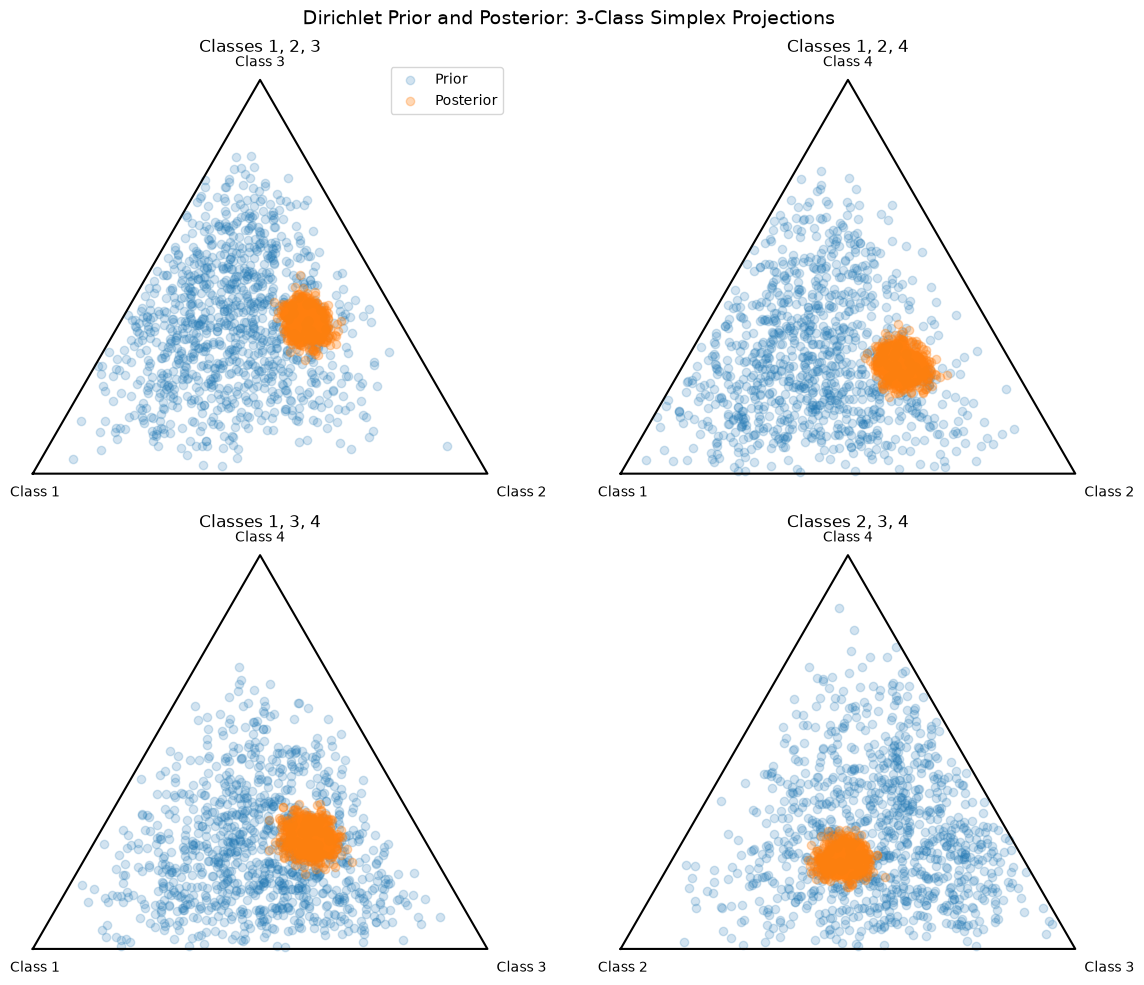

In [31]:
from scipy.stats import dirichlet

# visualize prior and posterior
prior = dirichlet(alpha)
posterior = dirichlet(alpha_n)

# generate samples
prior_samples = prior.rvs(size=1000)
posterior_samples = posterior.rvs(size=1000)

# class combinations
combinations = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, classes in zip(axes.ravel(), combinations):
    i, j, k = classes
    # normalize the selected 3 probabilities
    prior_3 = prior_samples[:, [i, j, k]]
    prior_3 = prior_3 / prior_3.sum(axis=1, keepdims=True)
    posterior_3 = posterior_samples[:, [i, j, k]]
    posterior_3 = posterior_3 / posterior_3.sum(axis=1, keepdims=True)

    # barycentric coordinates for an equilateral triangle
    x_prior = prior_3[:, 1] + 0.5 * prior_3[:, 2]
    y_prior = (np.sqrt(3) / 2) * prior_3[:, 2]
    x_post = posterior_3[:, 1] + 0.5 * posterior_3[:, 2]
    y_post = (np.sqrt(3) / 2) * posterior_3[:, 2]

    # plot prior and posterior
    ax.scatter(x_prior, y_prior, alpha=0.2, label="Prior")
    ax.scatter(x_post, y_post, alpha=0.3, label="Posterior")

    # triangle boundary
    triangle_x = [0, 1, 0.5, 0]
    triangle_y = [0, 0, np.sqrt(3) / 2, 0]
    ax.plot(triangle_x, triangle_y, "k-")

    # vertex labels
    ax.text(-0.05, -0.05, f"Class {i+1}")
    ax.text(1.02, -0.05, f"Class {j+1}")
    ax.text(0.5, np.sqrt(3)/2 + 0.03, f"Class {k+1}", ha="center")

    ax.set_title(f"Classes {i+1}, {j+1}, {k+1}")
    ax.set_aspect("equal")
    ax.axis("off")

axes[0, 0].legend()
plt.suptitle("Dirichlet Prior and Posterior: 3-Class Simplex Projections", fontsize=14)
plt.tight_layout()
plt.show()

**Plot Observations**
- The plots show the ***prior and posterior distributions*** for all four possible 3-class simplex projections to provide an ***equivalent 2D visualization of the 4-class Dirichlet distribution***.
- The ***posterior samples are more concentrated*** than the prior samples, indicating reduced uncertainty after observing the data.
- The posterior remains consistent with the constraint that the class probabilities are ***non-negative and sum to 1***.

## Part B: Probabilistic Supervised Learning (40 Marks)

### B1. Bayesian Logistic Regression using Laplace Approximation (15 Marks)

a) Generate a binary classification dataset containing 300 samples.

b) Assume a zero-mean Gaussian prior over model parameters.

c) Compute the MAP estimate.

d) Approximate the posterior using Laplace approximation.

e) Draw samples from the approximate posterior and visualize decision boundaries.

f) Compare predictions with standard MLE logistic regression.


In [32]:
from sklearn.datasets import make_classification

# generate 300 samples of binary classification
x, y = make_classification(n_samples=300, n_classes=2, n_features=2, n_redundant=0, n_informative=2, random_state=42)

print("BINARY CLASSIFICATION DATASET")
print("x shape =", x.shape)
print("y shape =", y.shape)
print("Class counts =", np.bincount(y))

BINARY CLASSIFICATION DATASET
x shape = (300, 2)
y shape = (300,)
Class counts = [150 150]


In [33]:
# zero-mean Gaussian prior
mu_0 = np.zeros(x.shape[1])
sigma_0 = 10

print("Gaussian Prior parameters")
print("mu_0 =", mu_0)
print("sigma_0 =", sigma_0)

Gaussian Prior parameters
mu_0 = [0. 0.]
sigma_0 = 10


In [34]:
from scipy.optimize import minimize
from scipy.special import expit

def negative_log_posterior(w):
    """
    log posterior = log likelihood + log prior
    return the negated result
    """
    probabilities = expit(x @ w)
    log_likelihood = np.sum(y * np.log(probabilities) + (1 - y) * np.log(1 - probabilities))
    log_prior = -0.5 * np.sum(w**2) / sigma_0**2
    return -(log_likelihood + log_prior)

w_0 = np.zeros(x.shape[1])                                      # initialize parameters
result = minimize(negative_log_posterior, w_0, method="BFGS")   # compute MAP estimate
w_map = result.x

print("MAP estimate:")
print("w_map =", w_map)
print("Optimization success =", result.success)

MAP estimate:
w_map = [4.03496416 0.66447521]
Optimization success = True


In [35]:
# compute probabilities at MAP estimate
p_map = expit(x @ w_map)

# compute Hessian of negative log-posterior
R = np.diag(p_map * (1 - p_map))
H = x.T @ R @ x + np.eye(x.shape[1]) / sigma_0**2

# Laplace approximation parameters
posterior_mean = w_map
posterior_covariance = np.linalg.inv(H)

print("Laplace Approximation of Posterior:")
print("Posterior mean =", posterior_mean)
print("Posterior covariance =\n", posterior_covariance)

Laplace Approximation of Posterior:
Posterior mean = [4.03496416 0.66447521]
Posterior covariance =
 [[0.24353821 0.05654349]
 [0.05654349 0.06219183]]


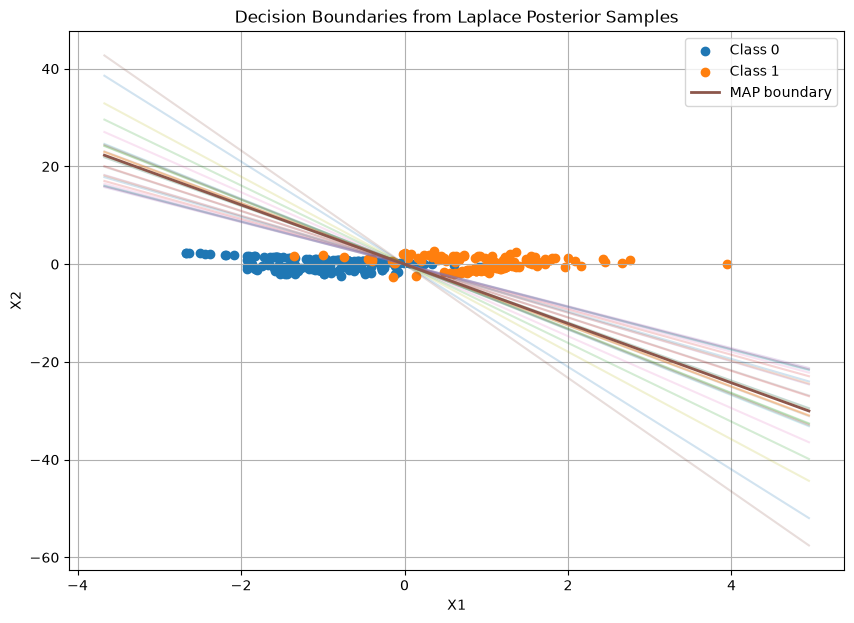

In [36]:
# draw samples from the approximate posterior
posterior_samples = np.random.multivariate_normal(mean=posterior_mean, cov=posterior_covariance, size=25)

# create grid for decision boundaries
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
x_grid = np.linspace(x_min, x_max, 200)

# plot data points
plt.figure(figsize=(10, 7))
plt.scatter(x[y == 0, 0], x[y == 0, 1], label="Class 0")
plt.scatter(x[y == 1, 0], x[y == 1, 1], label="Class 1")

# plot decision boundaries from posterior samples
for w in posterior_samples:
    y_grid = -(w[0] * x_grid) / w[1]
    plt.plot(x_grid, y_grid, alpha=0.2)

# plot MAP decision boundary
y_map = -(w_map[0] * x_grid) / w_map[1]
plt.plot(x_grid, y_map, linewidth=2, label="MAP boundary")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Decision Boundaries from Laplace Posterior Samples")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression

# fit standard MLE logistic regression
mle_model = LogisticRegression(C=1e6, l1_ratio=0, solver="lbfgs")
mle_model.fit(x, y)

# MLE predictions from sk learn
y_pred_mle = mle_model.predict(x)
y_prob_mle = mle_model.predict_proba(x)[:, 1]

# MAP predictions from our estimation model
y_prob_map = expit(x @ w_map)
y_pred_map = (y_prob_map >= 0.5).astype(int)

# compare predictions
print("MLE accuracy =", np.mean(y_pred_mle == y))
print("MAP accuracy =", np.mean(y_pred_map == y))
print("Different predictions =", np.sum(y_pred_mle != y_pred_map))

MLE accuracy = 0.9266666666666666
MAP accuracy = 0.9266666666666666
Different predictions = 0


**Comparison Observations**
- MLE and MAP logistic regression both achieved an ***accuracy of 92.67%***.
- Both models produced ***identical predictions*** for all 300 samples.
- Thus, the Gaussian prior had ***little effect*** on the final classification decisions.

### B2. Bayesian Linear Regression (15 Marks)
Generate regression data from
$$
y = 4x − 1 + ϵ, ϵ ∼ N (0, 0.8^2
).
$$

a) Assume a Gaussian prior over regression coefficients.

b) Derive the posterior analytically.

c) Plot the posterior over parameters after observing 20, 60, and 150 samples.

d) Compute the posterior predictive distribution.

e) Visualize predictive uncertainty.


In [38]:
# generate 100 regression samples from y = 4x − 1 + ϵ, ϵ ∼ N (0, 0.8^2)
n = 100
x = np.linspace(0, 10, n)
mu_noise = 0
sigma_noise = 0.8
epsilon = np.random.normal(loc=mu_noise, scale=sigma_noise, size=n)
y = 4 * x - 1 + epsilon

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (100,)
Shape of y: (100,)


In [39]:
# assume a Gaussian prior over regression coefficients
mu_0 = np.array([0.0, 0.0])
sigma_0 = np.array([
    [10.0, 0.0],
    [0.0, 10.0]
])
print("Prior mean:", mu_0)
print("Prior covariance:")
print(sigma_0)

Prior mean: [0. 0.]
Prior covariance:
[[10.  0.]
 [ 0. 10.]]


**Analytical Derivation of the Posterior**

Consider the linear regression model

$$
y = X\beta + \epsilon
$$

where

$$
\epsilon \sim \mathcal{N}(0,\sigma^2 I).
$$

For the given problem,

$$
\sigma = 0.8,
\qquad
\sigma^2 = 0.64.
$$

The design matrix is

$$
X =
\begin{bmatrix}
1 & x_1\
1 & x_2\
\vdots & \vdots\
1 & x_n
\end{bmatrix},
$$

and

$$
\beta =
\begin{bmatrix}
\beta_0\
\beta_1
\end{bmatrix}.
$$

The likelihood is therefore

$$
p(y\mid X,\beta) = \mathcal{N}(y\mid X\beta,\sigma^2 I).
$$

---

**1. Gaussian Prior**

Assume the Gaussian prior

$$
\beta \sim \mathcal{N}(\mu_0,\Sigma_0),
$$

with

$$
\mu_0 =
\begin{bmatrix}
0\
0
\end{bmatrix},
\qquad
\Sigma_0 =
\begin{bmatrix}
10 & 0\
0 & 10
\end{bmatrix}.
$$

The prior density is

$$
p(\beta)
\propto
\exp
\left[
-\frac{1}{2}
(\beta-\mu_0)^T
\Sigma_0^{-1}
(\beta-\mu_0)
\right].
$$

---

**2. Likelihood**

The likelihood is

$$
p(y\mid X,\beta)
\propto
\exp
\left[
-\frac{1}{2\sigma^2}
(y-X\beta)^T(y-X\beta)
\right].
$$

Since $\sigma^2 = 0.64$,

$$
p(y\mid X,\beta)
\propto
\exp
\left[
-\frac{1}{2(0.64)}
(y-X\beta)^T(y-X\beta)
\right].
$$

---

**3. Posterior Using Bayes' Rule**

Using

$$
p(\beta\mid X,y)
\propto
p(y\mid X,\beta)p(\beta),
$$

we obtain

$$
p(\beta\mid X,y)
\propto
\exp
\left[
-\frac{1}{2\sigma^2}
(y-X\beta)^T(y-X\beta)
-\frac{1}{2}
(\beta-\mu_0)^T
\Sigma_0^{-1}
(\beta-\mu_0)
\right].
$$

The posterior is also Gaussian:

$$
\boxed{
\beta\mid X,y \sim \mathcal{N}(\mu_n,\Sigma_n)
}
$$

---

**4. Expand the Likelihood Term**

Expand

$$
(y-X\beta)^T(y-X\beta)
$$

to obtain

$$
y^Ty - y^TX\beta - \beta^TX^Ty + \beta^TX^TX\beta.
$$

Since

$$
y^TX\beta = \beta^TX^Ty,
$$

we get

$$
y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta.
$$

Therefore,

$$
-\frac{1}{2\sigma^2}(y-X\beta)^T(y-X\beta)
$$

becomes

$$
-\frac{1}{2}\beta^T\left(\frac{X^TX}{\sigma^2}\right)\beta
+
\beta^T\frac{X^Ty}{\sigma^2}
+\text{constant}.
$$

---

**5. Expand the Prior Term**

Similarly,

$$
(\beta-\mu_0)^T\Sigma_0^{-1}(\beta-\mu_0)
$$

expands to

$$
\beta^T\Sigma_0^{-1}\beta
-2\beta^T\Sigma_0^{-1}\mu_0
+\mu_0^T\Sigma_0^{-1}\mu_0.
$$

Ignoring terms that do not depend on $\beta$,

$$
-\frac{1}{2}(\beta-\mu_0)^T\Sigma_0^{-1}(\beta-\mu_0)
$$

becomes

$$
-\frac{1}{2}\beta^T\Sigma_0^{-1}\beta
+
\beta^T\Sigma_0^{-1}\mu_0
+\text{constant}.
$$

---

**6. Combine the Terms**

Combining likelihood and prior gives

$$
-\frac{1}{2}\beta^T\left(\Sigma_0^{-1} + \frac{X^TX}{\sigma^2}\right)\beta
+
\beta^T\left(\Sigma_0^{-1}\mu_0 + \frac{X^Ty}{\sigma^2}\right)
+\text{constant}.
$$

Comparing with the Gaussian form

$$
-\frac{1}{2}(\beta-\mu_n)^T\Sigma_n^{-1}(\beta-\mu_n),
$$

we identify the posterior precision:

$$
\boxed{
\Sigma_n^{-1} = \Sigma_0^{-1} + \frac{X^TX}{\sigma^2}
}
$$

and therefore

$$
\boxed{
\Sigma_n = \left(\Sigma_0^{-1} + \frac{X^TX}{\sigma^2}\right)^{-1}
}.
$$

---

**7. Posterior Mean**

The linear term gives

$$
\Sigma_0^{-1}\mu_0 + \frac{X^Ty}{\sigma^2}.
$$

Thus,

$$
\boxed{
\mu_n = \Sigma_n\left(\Sigma_0^{-1}\mu_0 + \frac{X^Ty}{\sigma^2}\right)
}.
$$

So the posterior is

$$
\boxed{
\beta\mid X,y \sim \mathcal{N}(\mu_n,\Sigma_n)
}
$$

where

$$
\Sigma_n = \left(\Sigma_0^{-1} + \frac{X^TX}{0.64}\right)^{-1},
\qquad
\mu_n = \Sigma_n\frac{X^Ty}{0.64}.
$$

---

**8. Substituting the Chosen Prior**

For

$$
\mu_0 =
\begin{bmatrix}
0\
0
\end{bmatrix},
\qquad
\Sigma_0 = 10I,
$$

we have

$$
\Sigma_0^{-1} = 0.1I.
$$

Since $\mu_0 = 0$,

$$
\Sigma_0^{-1}\mu_0 = 0.
$$

Therefore,

$$
\Sigma_n =
\left(
0.1I + \frac{X^TX}{0.64}
\right)^{-1},
$$

and

$$
\mu_n =
\Sigma_n \frac{X^Ty}{0.64}.
$$

The posterior mean represents the Bayesian estimate of the intercept and slope, while the posterior covariance represents the remaining uncertainty after observing the data.



Posterior for n = 20
Posterior mean: [-0.90618161  3.70235671]
Posterior covariance:
[[ 0.1166683  -0.08862234]
 [-0.08862234  0.09264934]]

Posterior for n = 60
Posterior mean: [-1.05281158  3.97180728]
Posterior covariance:
[[ 0.04143431 -0.01034024]
 [-0.01034024  0.00347382]]

Posterior for n = 150
Posterior mean: [-1.22819914  4.0451568 ]
Posterior covariance:
[[ 0.02515495 -0.00375421]
 [-0.00375421  0.00075132]]


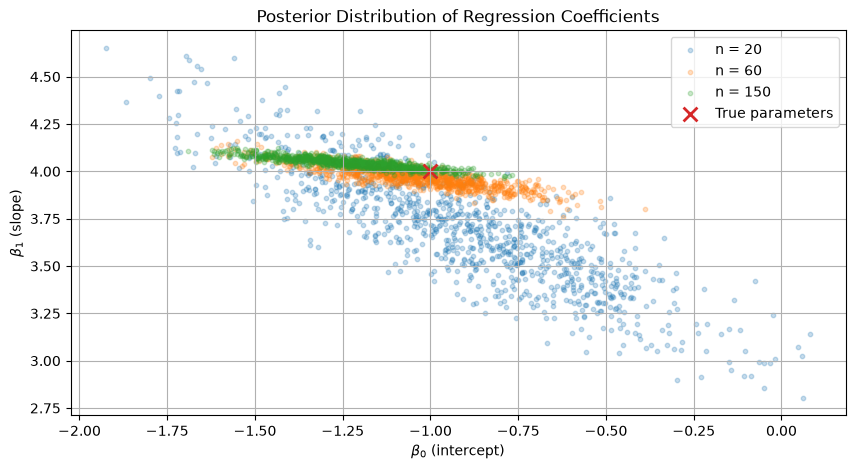

In [45]:
# plot the posterior over parameters after observing 20, 60, and 150 samples
sigma_sq = sigma_noise**2               # known noise variance
X = np.column_stack((np.ones(n), x))    # design matrix
sample_sizes = [20, 60, 150]            # posterior sample sizes

# plot posterior distributions
plt.figure(figsize=(10, 5))

for n_samples in sample_sizes:
    # select samples
    X_n = X[:n_samples]
    y_n = y[:n_samples]
    sigma_n = np.linalg.inv(np.linalg.inv(sigma_0) + X_n.T @ X_n / sigma_sq)    # posterior covariance
    mu_n = sigma_n @ (np.linalg.inv(sigma_0) @ mu_0 + X_n.T @ y_n / sigma_sq)   # posterior mean
    beta_samples = np.random.multivariate_normal(mu_n, sigma_n, 1000)           # draw samples from posterior

    # plot posterior samples
    plt.scatter(beta_samples[:, 0], beta_samples[:, 1], s=10, alpha=0.25, label=f"n = {n_samples}")
    print(f"\nPosterior for n = {n_samples}")
    print("Posterior mean:", mu_n)
    print("Posterior covariance:")
    print(sigma_n)

# true parameters
plt.scatter(-1, 4, marker="x", s=100, linewidths=2, label="True parameters")

plt.xlabel(r"$\beta_0$ (intercept)")
plt.ylabel(r"$\beta_1$ (slope)")
plt.title("Posterior Distribution of Regression Coefficients")
plt.legend()
plt.grid(True)
plt.show()

**Plot Observations**
- With ***20 samples***, the posterior has relatively high uncertainty around the regression coefficients.
- With ***60 samples***, the posterior becomes narrower and moves closer to the true parameters.
- With ***150 samples***, the posterior is highly concentrated around the true values $$(\beta_0=-1, \beta_1=4).$$
- Therefore, ***increasing the sample size reduces posterior uncertainty*** and provides more confident estimates of the regression coefficients.


In [46]:
# compute posterior predictive distribution
x_test = np.linspace(0, 10, 100)
X_test = np.column_stack((np.ones(len(x_test)), x_test))

# compute predictive stats
predictive_mean = X_test @ mu_n     
predictive_variance = sigma_sq + np.sum((X_test @ sigma_n) * X_test, axis=1)

print("Predictive mean shape:", predictive_mean.shape)
print("Predictive variance shape:", predictive_variance.shape)

Predictive mean shape: (100,)
Predictive variance shape: (100,)


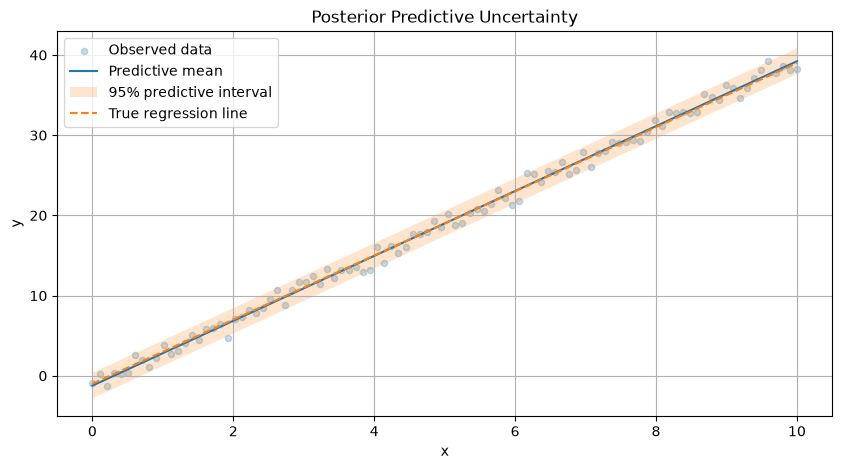

In [47]:
# visualize predictive uncertainty
predictive_std = np.sqrt(predictive_variance)
lower, upper = norm.interval(
    0.95,
    loc=predictive_mean,
    scale=predictive_std
)
plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=20, alpha=0.25, label="Observed data")
plt.plot(x_test, predictive_mean, label="Predictive mean")
plt.fill_between(x_test, lower, upper, alpha=0.2, label="95% predictive interval")

plt.plot(x_test, 4 * x_test - 1, "--", label="True regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior Predictive Uncertainty")
plt.legend()
plt.grid(True)
plt.show()

**Plot Observations**
- The ***posterior predictive mean*** follows the observed data closely and ***approaches the true regression line***.
- The shaded region represents the ***95% predictive interval***, showing the uncertainty in future observations.
- The predictive interval includes both ***parameter uncertainty*** and ***observation noise***.

### B3. Bayesian Multiclass Logistic Regression (10 Marks)

a) Generate a synthetic dataset containing 4 classes with 120 samples per class.

b) Assume Gaussian priors over model parameters.

c) Perform Bayesian inference using Laplace approximation.

d) Compute posterior predictive class probabilities.

e) Plot classification regions and uncertainty.

In [ ]:
# generate a synthetic dataset containing 4 classes with 120 samples per class.
n_per_class = 120
means = np.array([[2, 2], [7, 2], [2, 7], [7, 7]])  # class means (linearly separable)
cov = np.array([[1.0, 0.2], [0.2, 1.0]])            # covariance matrix (not much spreaded)

x = np.vstack([
    np.random.multivariate_normal(mean, cov, n_per_class) for mean in means
])                                                  # generate samples for each class
y = np.repeat(np.arange(4), n_per_class)            # create class labels

# print dataset information
print("Dataset shape:", x.shape)
print("Labels shape:", y.shape)
print("Samples per class:", np.bincount(y))

Dataset shape: (480, 2)
Labels shape: (480,)
Samples per class: [120 120 120 120]


In [50]:
# initialize Gaussian prior params
classes = 4
w_0 = np.zeros((classes, 2))
b_0 = np.zeros(classes)
sigma_0 = 10.0

w_prior = np.random.normal(w_0, np.sqrt(sigma_0), size=(classes, 2))
b_prior = np.random.normal(b_0, np.sqrt(sigma_0), size=classes)
print("Prior Weight shape:", w_prior.shape)
print("Prior Bias shape:", b_prior.shape)

Prior Weight shape: (4, 2)
Prior Bias shape: (4,)


In [51]:
# Bayesian inference using Laplace approximation
from scipy.optimize import minimize
from scipy.special import softmax

x = np.hstack([x, np.ones((x.shape[0], 1))])    # add bias term to input
classes = 4
d = x.shape[1]

def neg_log_posterior(theta):
    """
    log(posterior) = log(likelihood) + log(prior) 
    return negated result
    """
    theta = theta.reshape(classes, d)
    logits = x @ theta.T
    log_probs = logits - np.logaddexp.reduce(logits, axis=1, keepdims=True)
    log_likelihood = np.sum(log_probs[np.arange(len(y)), y])
    log_prior = -0.5 * np.sum(theta**2) / sigma_0
    return -(log_likelihood + log_prior)

theta_init = np.zeros((classes, d))     # initialize params

# find MAP estimate
result = minimize(neg_log_posterior, theta_init.ravel(), method="BFGS")
theta_map = result.x.reshape(classes, d)

print("MAP estimate:")
print(theta_map)
print("Optimization success:", result.success)

posterior_cov = np.asarray(result.hess_inv)         # approx. posterior covariance
posterior_hessian = np.linalg.inv(posterior_cov)    # approx. Hessian

print("Posterior covariance shape:", posterior_cov.shape)
print("Posterior Hessian shape:", posterior_hessian.shape)

MAP estimate:
[[-0.83075945 -0.83832447  9.76283319]
 [ 2.70900999 -2.91041708 -1.53311521]
 [-2.91224814  2.90633568 -2.06599438]
 [ 1.03402467  0.84239873 -6.16367842]]
Optimization success: True
Posterior covariance shape: (12, 12)
Posterior Hessian shape: (12, 12)


In [52]:
# compute posterior predictive class probabilities
# sample parameters from Laplace posterior
n_samples = 1000
theta_samples = np.random.multivariate_normal(result.x, posterior_cov, n_samples)

# compute posterior predictive class probabilities
logits = np.einsum("nd,sld->snl", x, theta_samples.reshape(n_samples, classes, d))
probs = softmax(logits, axis=2)
posterior_predictive = np.mean(probs, axis=0)

# predict class with maximum posterior predictive probability
y_pred = np.argmax(posterior_predictive, axis=1)

print("Posterior predictive shape:", posterior_predictive.shape)
print("Posterior predictive probabilities:")
print(posterior_predictive)

Posterior predictive shape: (480, 4)
Posterior predictive probabilities:
[[9.99637038e-01 1.60505501e-04 1.86487041e-04 1.59693656e-05]
 [7.68103157e-01 1.31994634e-05 2.31488446e-01 3.95197351e-04]
 [9.98506388e-01 2.96182772e-05 1.44844851e-03 1.55452471e-05]
 ...
 [7.52393762e-04 1.06712043e-03 4.45811246e-04 9.97734675e-01]
 [2.78755709e-03 1.07950098e-03 1.85826789e-03 9.94274674e-01]
 [6.53237735e-03 3.73504935e-01 4.18908763e-05 6.19920797e-01]]


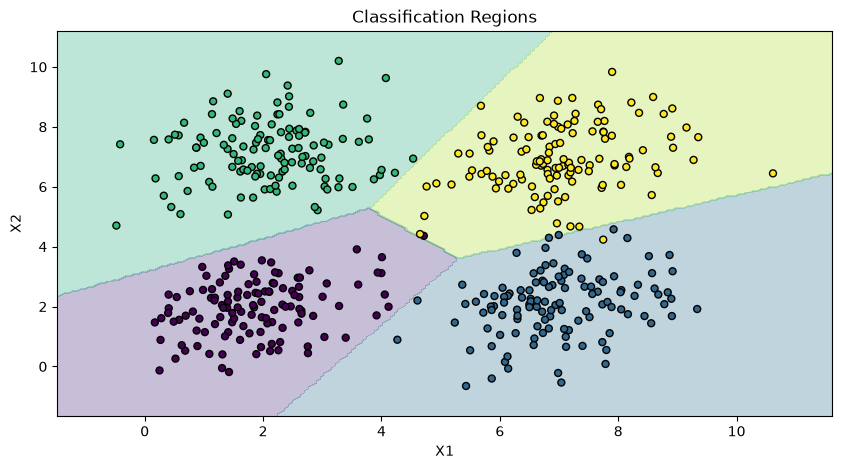

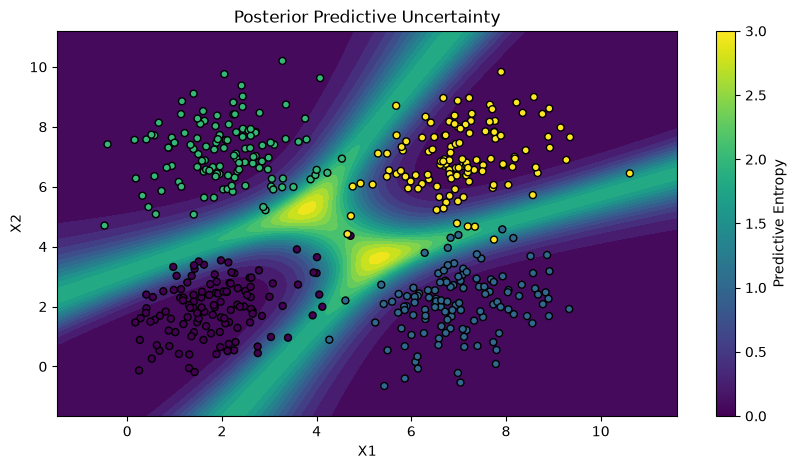

In [53]:
# plot classification regions and uncertainty
from scipy.special import softmax

# create grid for classification regions
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# create grid with bias term
grid = np.c_[x_grid.ravel(), x_grid.ravel() * 0, np.ones(x_grid.size)]
grid[:, 0] = x_grid.ravel()
grid[:, 1] = y_grid.ravel()

# reshape posterior samples
theta_samples_reshaped = theta_samples.reshape(n_samples, classes, d)

# compute posterior predictive probabilities
grid_logits = np.einsum("nd,sld->snl", grid, theta_samples_reshaped)
grid_probs = softmax(grid_logits, axis=2)
grid_predictive = np.mean(grid_probs, axis=0)

# predict class and compute uncertainty
grid_pred = np.argmax(grid_predictive, axis=1).reshape(x_grid.shape)
uncertainty = -np.sum(grid_predictive * np.log(grid_predictive + 1e-12), axis=1).reshape(x_grid.shape)

# plot classification regions
plt.figure(figsize=(10, 5))
plt.contourf(x_grid, y_grid, grid_pred, levels=np.arange(classes + 1) - 0.5, alpha=0.3)
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolor="black", s=25)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Classification Regions")
plt.show()

# plot predictive uncertainty
plt.figure(figsize=(10, 5))
plt.contourf(x_grid, y_grid, uncertainty, levels=20)
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolor="black", s=25)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Posterior Predictive Uncertainty")
plt.colorbar(label="Predictive Entropy")
plt.show()

**Plot Observations**
- The model ***effectively separates*** the four classes into distinct regions.
- Decision boundaries are ***approximately linear*** and lie between class clusters.
- Most observations are confidently classified within their respective regions.
- Samples near the boundaries show ***higher classification uncertainty (predictive entropy)***.

---
End of the assignment